In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

This notebook can be run after running Katydid with the `01_bkgSubtractedSpec.yaml` configuration.

Often, we want to convert bin edges into bin centers for plotting, so we define a function to achieve this.

In [2]:
def edges2centers(edges_array):
    return (edges_array[:-1] + edges_array[1:])/2

# Step 1 : RF Background Removal

The first step in reconstruction is to remove the frequency dependent background due to the RF readout chain. To achieve this, Katydid takes in a noise-only egg file (ie. `egg1` in our config) where it calculates the average PSD and fits a spline to it. This background is then subtracted when analyzing the egg file with signal (ie. `egg2`). The `gain-variation` processor performs the fit to the noise-only data as:

```yaml
      - signal: "egg1:header"
        slot: "fft1:header"
      - signal: "egg1:ts"
        slot: "fft1:ts-fftw"
      - signal: "fft1:fft"
        slot: "to-ps1:fs-fftw-to-psd"
      - signal: "to-ps1:psd"
        slot: "acc:ps"
      - signal: "acc:ps-finished"
        slot: "gainvar:ps-var"
      - signal: "acc:ps-finished"
        slot: "writer:psd"                 # Write accumulated PSD histogram
      - signal: "gainvar:gain-var"
        slot: "writer:gain-var"            # Write gain-var histogram
      - signal: "gainvar:gain-var"
        slot: "discrim:gv"
```

Each time-series slice in the `egg1` is converted into a PSD and accumulated (ie. `acc` above). Once it goes through all time slices, the accumulated PSD's are averaged and the fit is performed (ie. `gainvar:ps-var` above). Finally, that fit data is passed into the `discriminator` processor, which later performs the subtraction when iterating through the slices of the signal file.

## Step 1.1 : Fit Noise Background

We have written the data of the averaged PSDs and the fit, which we plot as follows:

In [3]:
basicFile = uproot.open('bkgSubtractedSpec_basic.root')
basicFile.classnames()

{'histGV_400_0;2': 'TH1D',
 'histGV_400_0;1': 'TH1D',
 'histGVVar_400_0;2': 'TH1D',
 'histGVVar_400_0;1': 'TH1D',
 'histPSD_400_0;2': 'TH1D',
 'histPSD_400_0;1': 'TH1D'}

The `gain-variation` processor also calculates the variance in each bin, but we will not plot that here. The variance is used to normalize the power (for a Phase II example see C. Claessens PhD Thesis Eq.(7.4)). Feel free to plot it yourself as an exercise! In the configuration, we fixed the number of slices to be 400.

(0.0, 4e-13)

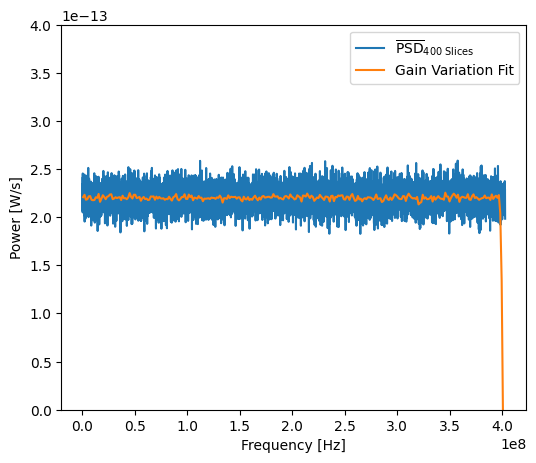

In [4]:
avgPSDData = basicFile['histPSD_400_0;1'].to_numpy()
avgPSDVals = avgPSDData[0]
avgPSDEdges = avgPSDData[1]
avgPSDCenters = edges2centers(avgPSDEdges)

gainMeanData = basicFile['histGV_400_0;1'].to_numpy()
gainMeanVals = gainMeanData[0]
gainMeanEdges = gainMeanData[1]
gainMeanCenters = edges2centers(gainMeanEdges)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(avgPSDCenters, avgPSDVals, label=r'$\overline{\text{PSD}}_\text{400 Slices}$')
ax.plot(gainMeanCenters, gainMeanVals, label='Gain Variation Fit')
ax.legend()
ax.set_ylabel('Power [W/s]')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylim([0, 4.e-13])

Note, the background is flat. This is just what it is currently set as in CCA simulations, the real background will include the cavity resonance shape and other features from the RF chain. In Phase II, the background had non-trivial frequency dependence, which is why it had to be fit with a spline (see C. Claessens PhD Thesis Fig 7.2).



We also output the signal spectrogram with no processing in:

```yaml
      - signal: "to-ps2:psd"
        slot: "specwriter:psd"
      - signal: "egg2:egg-done"
        slot: "specwriter:write-file"
```

To plot the spectrogram we use `pcolormesh` which expects data in (y,x) so we transpose the power data, and we use a log color scale for better visualization.

In [5]:
specFile = uproot.open('bkgSubtractedSpec_spectrogram.root')
specFile.classnames()

{'PSDSpectrogram_0_0;2': 'TH2D', 'PSDSpectrogram_0_0;1': 'TH2D'}

Text(0, 0.5, 'Frequency [Hz]')

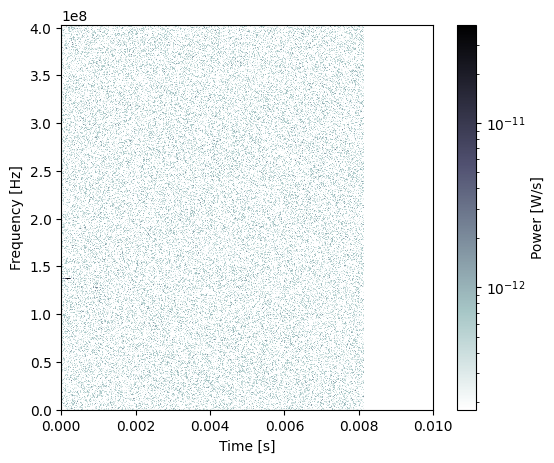

In [6]:
from matplotlib.colors import LogNorm

specData = specFile['PSDSpectrogram_0_0;1'].to_numpy()
specPower = specData[0]
specTimeBinEdges = specData[1]
specFreqBinEdges = specData[2]

fig, ax = plt.subplots(figsize=(6,5))
mesh = ax.pcolormesh(specTimeBinEdges, specFreqBinEdges, np.transpose(specPower), norm=LogNorm(vmin=np.mean(specPower)), cmap='bone_r')
colorbar = fig.colorbar(mesh, ax=ax, label='Power [W/s]')
# ax.set_xlim([0,3.1e-3])
# ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')

## Step 1.2 : Background Removal and Sparse Spectrogram Generation

The last addition to this configuration from the original `00_barebones.yaml` config was applying the `discriminator` processor. Recall, we gave the background fit data to `discrim` in step 1 above, and now it is used here to keep only high power bins according to a given threshold. In our configuration, this threshold is `sigma-threshold` (ie. in `discrim`), which is set to 9. This means that all bins, $i$, for which the power is $P_i < \mu_i + 9\cdot \sigma_i$ are set to zero, where $\mu_i$ and $\sigma_i$ and the background mean and variance of the $i$th bin calculated by the `gain-variation` processor in step 1. This process results in keeping only bins with power above that threshold, creating what we call a "sparse spectrogram". We output the bins above threshold in 

```yaml
      - signal: "discrim:disc-1d"
        slot: "treewriter:disc-1d" 
```

Now, we plot this sparse spectrogram

In [7]:
treeFile = uproot.open('bkgSubtractedSpec_tree.root')
treeFile.classnames()

{'discPoints1D;2': 'TTree', 'discPoints1D;1': 'TTree'}

In this ROOT file, the data is stored in a TTree

In [8]:
sparseSpecTree = treeFile['discPoints1D;1']
sparseSpecTree.keys()

['Slice',
 'TimeInRunC',
 'Component',
 'Bin',
 'Abscissa',
 'Ordinate',
 'Threshold',
 'Mean',
 'Variance',
 'NeighborhoodAmplitude']

We just want to plot the sparse spectrogram, so we only extract the relevant data

Text(0, 0.5, 'Frequency [Hz]')

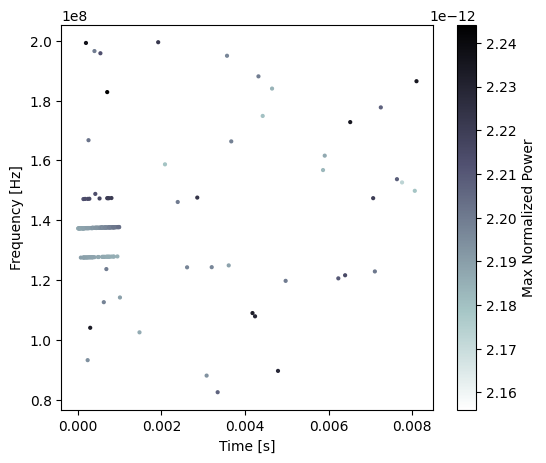

In [9]:
sparseSpecTreeBranches = ['TimeInRunC', 'Abscissa', 'Threshold']

sparseSpecData = {}
sparseSpecData = sparseSpecTree.arrays(sparseSpecTreeBranches, library='np')

sparseSpecTimes = sparseSpecData['TimeInRunC']
sparseSpecFreqs = sparseSpecData['Abscissa']
sparseSpecThresholds = sparseSpecData['Threshold']

fig, ax = plt.subplots(figsize=(6,5))
sparseSpecPlot = ax.scatter(sparseSpecTimes, sparseSpecFreqs, c=sparseSpecThresholds, cmap='bone_r', s=4)
fig.colorbar(sparseSpecPlot, label='Max Normalized Power')
# ax.set_xlim([0,3.1e-3])
# ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')

To summarize, we reached a stage in reconstruction where we are ready to construct CRES tracks in spectrograms. We started by fitting the background and normalizing the data in each frequency bin. Thereafter, we iterated through the spectrogram slice-by-slice keeping only bins with power above some configured threshold parameter resulting in the sparse spectrogram above. Optional exploration: modify the `sigma-threshold` parameter and see how that changes the spectrogram above(it will also influence the run time in track finding, why?), or modify the number of slices or slice size and predict what will change.